In [9]:
"""
绘制镜像谱：
    给定谱图(peaks)、peptide(seq+mod)、pPred的ms2预测结果，绘制镜像谱
"""
import matplotlib.pyplot as plt
import numpy as np

In [33]:
def draw_mirror_spectrum(exp_ms2, pred_ms2, title="Mirror Spectra"):
    """
    绘制镜像谱图（实验谱图在上，预测谱图在下）
    
    参数：
    exp_ms2: 实验谱图数据 [(ion_type, mz, normalized_intensity), ...]
    pred_ms2: 预测谱图数据 [(ion_type, mz, normalized_intensity), ...]
    title: 图像标题
    """
    # 提取数据
    exp_ions, exp_mz, exp_inten = zip(*exp_ms2) if exp_ms2 else ([], [], [])
    pred_ions, pred_mz, pred_inten = zip(*pred_ms2) if pred_ms2 else ([], [], [])
    
    # 处理数据
    exp_inten = np.array(exp_inten)
    pred_inten = np.array(pred_inten)
    
    # 计算坐标范围
    max_intensity = max(exp_inten.max() if exp_inten.size else 0, 
                        pred_inten.max() if pred_inten.size else 0)
    y_limit = max_intensity * 1.2 if max_intensity != 0 else 1.0
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("m/z", fontsize=12)
    ax.set_ylabel("Normalized Intensity", fontsize=12)
    # ax.set_xlim(min_mz, max_mz)
    ax.set_ylim(-y_limit, y_limit)
    
    # 绘制实验谱图（上方）
    for ion, mz, inten in zip(exp_ions, exp_mz, exp_inten):
        if inten <= 0:
            continue
        ax.vlines(mz, 0, inten, color="#1f77b4", lw=2, label="Experimental" if ion == exp_ions[0] else "")  # 蓝色线条
        ax.text(mz, inten + 0.05*y_limit, ion, 
                ha='center', va='bottom', fontsize=8, rotation=45, color="#1f77b4")  # 上方标注
    
    # 绘制预测谱图（下方）
    for ion, mz, inten in zip(pred_ions, pred_mz, pred_inten):
        if inten <= 0:
            continue
        ax.vlines(mz, 0, -inten, color="#d62728", lw=2, label="Predicted" if ion == pred_ions[0] else "")  # 红色线条
        ax.text(mz, -inten - 0.05*y_limit, ion, 
                ha='center', va='top', fontsize=8, rotation=45, color="#d62728")  # 下方标注
    
    # 添加水平轴
    ax.axhline(0, color='black', lw=1.5)
    
    # 美化设置
    ax.grid(True, linestyle='--', alpha=0.7, axis='x')
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.legend(loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()

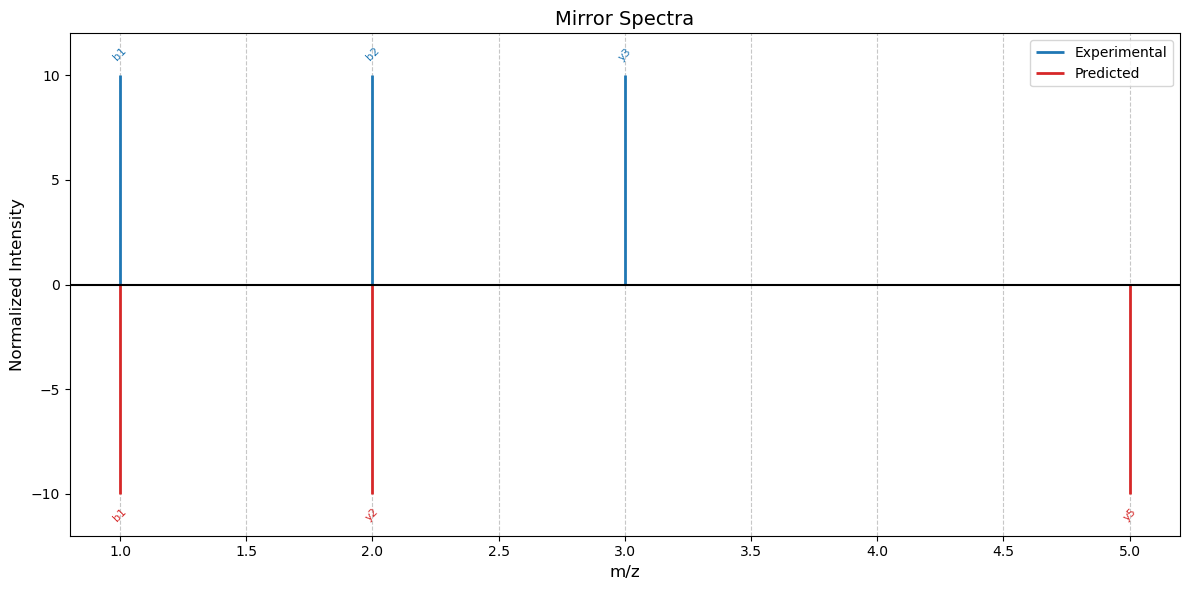

In [35]:
exp_ms2 = [('b1',1,10), ('b2',2,10), ('y3',3,10)]
pred_ms2 = [('b1',1,10), ('y2',2,10), ('y5',5,10)]
draw_mirror_spectrum(exp_ms2, pred_ms2)